In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Задача

В приложенных файлах вы увидите данные по прохождению студентами тестов на образовательной платформе. Такие данные могут быть использованы для построения персонализированных ИИ-ассистентов для поддержки обучения студента. На текущем этапе сосредоточимся на начальном этапе — сборе и подготовке данных.

<b>Вам необходимо:</b>

Используя библиотеку pandas (или аналоги), проанализировать как можно больше характеристик, влияющих на успеваемость студентов.
https://www.kaggle.com/competitions/riiid-test-answer-prediction/data

# Загрузка данных

#### lectures.csv

* **lecture_id:** внешний ключ для столбца content_id в обучающем/тестовом наборе, когда тип контента - лекция (1).

* **part:** код верхнего уровня категории для лекци
  
* **tag:** один код тега для лекции. Значение тегов не будет предоставлено, но эти коды достаточны для кластеризации лекций вмес- **е.

* **type_of:** краткое описание основной цели лекции.

In [5]:
lectures = pd.read_csv("lectures.csv")
lectures.info()
lectures.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   lecture_id  418 non-null    int64 
 1   tag         418 non-null    int64 
 2   part        418 non-null    int64 
 3   type_of     418 non-null    object
dtypes: int64(3), object(1)
memory usage: 13.2+ KB


(418, 4)

In [7]:
lectures.head()

,lecture_id,tag,part,type_of
0,89,159,5,concept
1,100,70,1,concept
2,185,45,6,concept
3,192,79,5,solving question
4,317,156,5,solving question


In [9]:
# Проверяем основные статистические характеристики 
lectures.describe()

,lecture_id,tag,part
count,418.000000,418.000000,418.000000
mean,16983.401914,94.480861,4.267943
std,9426.164660,53.586487,1.872424
min,89.000000,0.000000,1.000000
25%,9026.250000,50.250000,2.000000
50%,17161.500000,94.500000,5.000000
75%,24906.250000,140.000000,6.000000
max,32736.000000,187.000000,7.000000


In [11]:
# проверяем дополнительно датафрейм на пропцуски в данных
missing_values = lectures.isna().sum()
print(missing_values)

lecture_id    0
tag           0
part          0
type_of       0
dtype: int64


#### questions.csv

* **question_id:** внешний ключ для столбца content_id в наборе данных для обучения/тестирования, когда тип содержимого — вопрос (0).

* **bundle_id:** код, указывающий, какие вопросы предоставляются вместе.

* **correct_answer:** ответ на вопрос. Может быть сопоставлен со столбцом user_answer в наборе данных для обучения, чтобы проверить, был ли пользователь прав.

* **part:** соответствующий раздел теста TOEIC.

* **tags:** один или несколько детализированных кодов тегов для вопроса. Значение тегов не будет предоставлено, но эти коды являются достаточными для группировки вопросов вместе.

In [13]:
questions = pd.read_csv("questions.csv")
questions.info()
questions.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13523 entries, 0 to 13522
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   question_id     13523 non-null  int64 
 1   bundle_id       13523 non-null  int64 
 2   correct_answer  13523 non-null  int64 
 3   part            13523 non-null  int64 
 4   tags            13522 non-null  object
dtypes: int64(4), object(1)
memory usage: 528.4+ KB


(13523, 5)

In [15]:
questions.head()

,question_id,bundle_id,correct_answer,part,tags
0,0,0,0,1,51 131 162 38
1,1,1,1,1,131 36 81
2,2,2,0,1,131 101 162 92
3,3,3,0,1,131 149 162 29
4,4,4,3,1,131 5 162 38


In [17]:
# Проверяем основные статистические характеристики 
questions.describe()

,question_id,bundle_id,correct_answer,part
count,13523.00000,13523.000000,13523.000000,13523.000000
mean,6761.00000,6760.510907,1.455298,4.264956
std,3903.89818,3903.857783,1.149707,1.652553
min,0.00000,0.000000,0.000000,1.000000
25%,3380.50000,3379.500000,0.000000,3.000000
50%,6761.00000,6761.000000,1.000000,5.000000
75%,10141.50000,10140.000000,3.000000,5.000000
max,13522.00000,13522.000000,3.000000,7.000000


In [19]:
# проверяем дополнительно датафрейм на пропцуски в данных
missing_values = questions.isna().sum()
print(missing_values)

question_id       0
bundle_id         0
correct_answer    0
part              0
tags              1
dtype: int64


#### train.csv

In [21]:
train = pd.read_csv("train.csv")
train.info()
train.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101230332 entries, 0 to 101230331
Data columns (total 10 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   row_id                          int64  
 1   timestamp                       int64  
 2   user_id                         int64  
 3   content_id                      int64  
 4   content_type_id                 int64  
 5   task_container_id               int64  
 6   user_answer                     int64  
 7   answered_correctly              int64  
 8   prior_question_elapsed_time     float64
 9   prior_question_had_explanation  object 
dtypes: float64(1), int64(8), object(1)
memory usage: 7.5+ GB


(101230332, 10)

In [22]:
train.head()

,row_id,timestamp,user_id,content_id,content_type_id,task_container_id,user_answer,answered_correctly,prior_question_elapsed_time,prior_question_had_explanation
0,0,0,115,5692,0,1,3,1,NaN,NaN
1,1,56943,115,5716,0,2,2,1,37000.0,False
2,2,118363,115,128,0,0,0,1,55000.0,False
3,3,131167,115,7860,0,3,0,1,19000.0,False
4,4,137965,115,7922,0,4,1,1,11000.0,False


In [23]:
# Проверяем основные статистические характеристики 
train.describe()

,row_id,timestamp,user_id,content_id,content_type_id,task_container_id,user_answer,answered_correctly,prior_question_elapsed_time
count,1.012303e+08,1.012303e+08,1.012303e+08,1.012303e+08,1.012303e+08,1.012303e+08,1.012303e+08,1.012303e+08,9.887879e+07
mean,5.061517e+07,7.703644e+09,1.076732e+09,5.219605e+03,1.935222e-02,9.040624e+02,1.376123e+00,6.251644e-01,2.542381e+04
std,2.922268e+07,1.159266e+10,6.197163e+08,3.866359e+03,1.377596e-01,1.358302e+03,1.192896e+00,5.225307e-01,1.994815e+04
min,0.000000e+00,0.000000e+00,1.150000e+02,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,-1.000000e+00,0.000000e+00
25%,2.530758e+07,5.243436e+08,5.408116e+08,2.063000e+03,0.000000e+00,1.040000e+02,0.000000e+00,0.000000e+00,1.600000e+04
50%,5.061517e+07,2.674234e+09,1.071781e+09,5.026000e+03,0.000000e+00,3.820000e+02,1.000000e+00,1.000000e+00,2.100000e+04
75%,7.592275e+07,9.924551e+09,1.615742e+09,7.425000e+03,0.000000e+00,1.094000e+03,3.000000e+00,1.000000e+00,2.966600e+04
max,1.012303e+08,8.742577e+10,2.147483e+09,3.273600e+04,1.000000e+00,9.999000e+03,3.000000e+00,1.000000e+00,3.000000e+05


In [24]:
# проверяем дополнительно датафрейм на пропцуски в данных
missing_values = train.isna().sum()
print(missing_values)

row_id                                  0
timestamp                               0
user_id                                 0
content_id                              0
content_type_id                         0
task_container_id                       0
user_answer                             0
answered_correctly                      0
prior_question_elapsed_time       2351538
prior_question_had_explanation     392506
dtype: int64


* **row_id:** (int64) Код идентификатора строки.
* **timestamp:** (int64) Время в миллисекундах между этим взаимодействием пользователя и первым завершением события от этого пользователя.
* **user_id:** (int32) Код идентификатора пользователя.
* **content_id:** (int16) Код идентификатора взаимодействия пользователя.
* **content_type_id:** (int8) 0, если событие было вопросом, заданным пользователю; 1, если событие заключалось в том, что пользователь смотрел лекцию.
* **task_container_id:** (int16) Код идентификатора пакета вопросов или лекций. Например, пользователь может увидеть три вопроса подряд перед тем, как увидеть объяснения для любого из них. Все три будут иметь одинаковый task_container_id.
* **user_answer:** (int8) Ответ пользователя на вопрос, если он есть. Читайте -1 как null для лекций.
* **answered_correctly:** (int8) Успешно ли ответил пользователь. Читайте -1 как null для лекций.
* **prior_question_elapsed_time:** (float32) Среднее время в миллисекундах, которое потребовалось пользователю, чтобы ответить на каждый вопрос в предыдущем наборе вопросов, игнорируя любые лекции между ними. Отсутствует для первого набора вопросов или лекции пользователя. Обратите внимание, что время — это среднее время, затраченное пользователем на решение каждого вопроса в предыдущем пакете.
* **prior_question_had_explanation:** (булевое значение) Указывает, видел ли пользователь объяснение и правильные ответы после ответа на предыдущий пакет вопросов, игнорируя любые лекции между ними. Значение разделяется между одним пакетом вопросов и равно null для первого пакета вопросов или лекции пользователя. Обычно первые несколько вопросов, которые видит пользователь, являются частью диагностического теста при вводе, где они не получили никакой обратной связи.

# Анализ lectures.csv

In [25]:
# Считаем количество уникальных lecture_id в каждом part
lectures_count = lectures.groupby('part')['lecture_id'].nunique().reset_index()

# Переименовываем колонки для удобства
lectures_count.columns = ['part', 'unique_lecture_count']
print(lectures_count)

   part  unique_lecture_count
0     1                    54
1     2                    56
2     3                    19
3     4                    31
4     5                   143
5     6                    83
6     7                    32


In [37]:
# Проверим уникальные части
print(lectures['part'].unique())

[5 1 6 2 7 3 4]


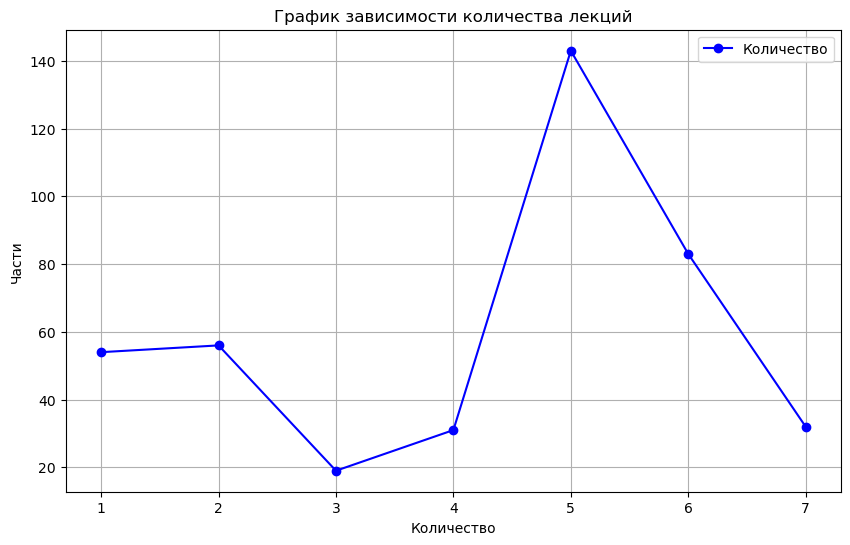

In [45]:
# Построение графика зависимости количества лекций
plt.figure(figsize=(10, 6))
plt.plot(lectures_count['part'], lectures_count['unique_lecture_count'], marker='o', linestyle='-', color='b', label='Количество')  # линия с маркерами
plt.title('График зависимости количества лекций')
plt.xlabel('Количество')
plt.ylabel('Части')
plt.legend()
plt.grid()
plt.show() 

# Анализ questions.csv и train.csv

In [52]:
# Получаем общее количество ответов в массиве данных
total_amount_answers = train.shape[0]

In [56]:
# Получаем общее количество ответов, которые были связанны с лекцией
count_answers_on_lections = train[train['user_answer'] == -1].shape[0]
print(f"Количество ответов на лекции составляет {round(count_answers_on_lections / total_amount_answers,3) } %")

Количество ответов на лекции составляет 0.019 %


In [59]:
# Убираем все строки, которые не связаны с тестированием
train_df = train[train['user_answer'] != -1]
# Выводим значение с актуальным количеством строк
total_amount_answers = train_df.shape[0]
print(f"Количество строк после сокращения данных строк, связанной с лекцией {total_amount_answers}")

Количество строк после сокращения данных строк, связанной с лекцией 99271300


In [60]:
# Получаем количество правильных ответов
count_correctly_answers = train_df[train_df['answered_correctly'] == 1].shape[0]
print(f"Общее количество правильных ответов состовляет {round(count_correctly_answers / total_amount_answers,4)} %")

Общее количество правильных ответов состовляет 0.6572 %
